<a href="https://colab.research.google.com/github/adarsha4real/pytorch-basics/blob/main/pytorch_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural network classification in pytorch

make classification data and get it ready

In [1]:
import sklearn

In [2]:
from sklearn.datasets import make_circles
#  make 1000 samples
n_sample=1000

# create circles
X,Y = make_circles(n_sample,
                   noise=0.03,
                   random_state=42)

In [3]:
len(X),len(Y)


(1000, 1000)

In [4]:
print(f"first 5 samples of X:\n {X[:5]}")
print(f"first 5 samples of Y:\n {Y[:5]}")

first 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
first 5 samples of Y:
 [1 1 1 1 0]


In [5]:
# make data frame of circle data
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0],
                      "X2":X[:,1],
                      "label":Y

                     })

circles.head(5)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


visualize the data

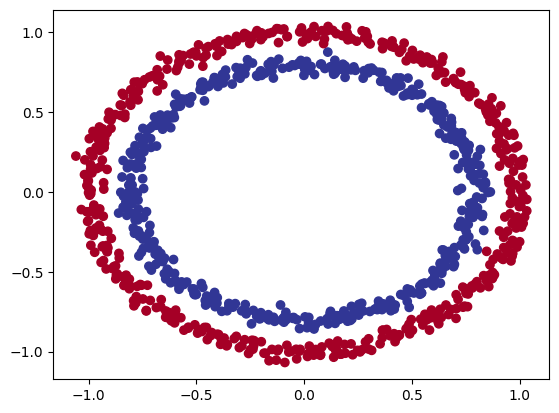

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=Y,
            cmap=plt.cm.RdYlBu);



## Turing our data to tensos
1.1 check the shapes of both input and output

In [7]:
X.shape,Y.shape

((1000, 2), (1000,))

In [8]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

1.2 turn the data into tenors

In [9]:
import torch
torch.__version__

'2.11.0+cu128'

In [10]:
X.dtype,type(X)

(dtype('float64'), numpy.ndarray)

In [11]:
X = torch.tensor(X, dtype=torch.float)
Y = torch.tensor(Y, dtype=torch.float)

In [12]:
X[:5],Y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [13]:
type(X),X.dtype,Y.dtype


(torch.Tensor, torch.float32, torch.float32)

#split data into test and train data set

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,
                                                 random_state=42)

In [15]:
len(X_train),len(X_test),len(Y_train),len(Y_test)

(800, 200, 800, 200)

##Building The Model

In [16]:
import torch
from torch import nn

In [17]:
# make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Construct a Model

In [18]:
class CircleModelv0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=5)
    self.layer_2 = nn.Linear(in_features=5,out_features=1)

  def forward(self,X):
    return self.layer_2(self.layer_1(X)) # x -> layer_1 --> layer_2



model_0=CircleModelv0().to(device)
model_0



CircleModelv0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

## Replicating above model using nn.Sequential()

In [19]:
model_0= nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)

model_0


Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

## Make prediction through Model

In [20]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1115, -0.2255],
                      [-0.0817,  0.5298],
                      [-0.1050, -0.6353],
                      [-0.6393,  0.2947],
                      [ 0.4395,  0.1739]], device='cuda:0')),
             ('0.bias',
              tensor([-0.3251,  0.4368, -0.4359,  0.3647, -0.4748], device='cuda:0')),
             ('1.weight',
              tensor([[-0.1037, -0.2394, -0.1152,  0.2119,  0.0757]], device='cuda:0')),
             ('1.bias', tensor([-0.2498], device='cuda:0'))])

In [21]:
# untrained predictions
with torch.inference_mode():
  untrained_pred= model_0(X_test.to(device))




In [22]:
# setup a loss function
# we use BCEwithLogitsLoss as it has builtin sigm,oid function which is an activation function
Loss_fn=nn.BCEWithLogitsLoss()
Optimizer=torch.optim.SGD(params=model_0.parameters(),
                          lr=0.1,

                          )

In [23]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1115, -0.2255],
                      [-0.0817,  0.5298],
                      [-0.1050, -0.6353],
                      [-0.6393,  0.2947],
                      [ 0.4395,  0.1739]], device='cuda:0')),
             ('0.bias',
              tensor([-0.3251,  0.4368, -0.4359,  0.3647, -0.4748], device='cuda:0')),
             ('1.weight',
              tensor([[-0.1037, -0.2394, -0.1152,  0.2119,  0.0757]], device='cuda:0')),
             ('1.bias', tensor([-0.2498], device='cuda:0'))])

In [24]:
# calculate the accuracy
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc

In [25]:
# going from raw logits --> predicion probaility -->predicton labels
# our model oupput are goin to be raw logits
# we can convert the raw logits into prediction probability by passing it through a activation function (e.g: sigmoid for binarycross entrophy and softmax for multiclass )
# we can convert th prediction probability into prediction labels by either rounding them or taking argmax().
model_0.eval()
with torch.inference_mode():

  y_logits= model_0(X_test.to(device))[:5]
y_logits


tensor([[-0.1673],
        [-0.1868],
        [-0.1857],
        [-0.1618],
        [-0.2959]], device='cuda:0')

In [26]:
Y_test[:5]

tensor([1., 0., 1., 0., 1.])

use the sigmoid function on our model

In [27]:
y_pred_prob=torch.sigmoid(y_logits)
y_pred_prob

tensor([[0.4583],
        [0.4534],
        [0.4537],
        [0.4596],
        [0.4266]], device='cuda:0')

for our prediction probability values, we need  to perform  a range style rouning on them:
* y_pred_prob >=0.5 --> round to y=1 (class 1)
* y_pred_prob < 0.5 --> round to y=0 (class 0)


In [28]:
y_preds = torch.round(y_pred_prob)

In [29]:
Y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [30]:
# find the predicted labels
y_preds = torch.round(y_pred_prob)

# or
y_pred_labels= torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# checking whether y_preds and y_pred_labels are equal or not
torch.eq(y_preds.squeeze(),y_pred_labels.squeeze())


y_preds.squeeze() # getting rid of extra dimension

tensor([0., 0., 0., 0., 0.], device='cuda:0')

building a training and test loop

In [31]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

# put the data to target device
X_train,Y_train, = X_train.to(device), Y_train.to(device)
X_test,Y_test=X_test.to(device),Y_test.to(device)
# building train and evaluate loop
for epoch in range (epochs):
  model_0.train()
  # 1.forward pass
  y_logits= model_0(X_train).squeeze()
  y_preds=torch.round(torch.sigmoid(y_logits)) # turn logits --> pred probs --> pred labels
  # 2. calculate the loss/accuracy
  loss=Loss_fn(y_logits,Y_train)
  accuracy=accuracy_fn(y_true=Y_train,
                       y_pred=y_preds)

  # 3. optimizer zero grad
  Optimizer.zero_grad()

  # 4. loss backward
  loss.backward()

  #5. optimizer jump step
  Optimizer.step()


  # testing

  model_0.eval()
  with torch.inference_mode():
    #1.forward pass
    test_logits= model_0(X_test).squeeze()
    test_pred= torch.round(torch.sigmoid(test_logits))

    #2.calculate test loss
    test_loss=Loss_fn(test_logits,Y_test)
    test_acc=accuracy_fn(y_true=Y_test,
                         y_pred=test_pred)
  if epoch % 10 == 0:
    print(f"Epoch:{epoch} | loss:{loss:.5f}, accuracy: {accuracy:.2f} % |test_loss:{test_loss:.5f}|| test_acc:{test_acc:.2f}%")

Epoch:0 | loss:0.70013, accuracy: 50.00 % |test_loss:0.69953|| test_acc:50.00%
Epoch:10 | loss:0.69631, accuracy: 50.00 % |test_loss:0.69654|| test_acc:50.00%
Epoch:20 | loss:0.69490, accuracy: 46.50 % |test_loss:0.69557|| test_acc:44.00%
Epoch:30 | loss:0.69433, accuracy: 48.62 % |test_loss:0.69525|| test_acc:44.50%
Epoch:40 | loss:0.69405, accuracy: 49.62 % |test_loss:0.69512|| test_acc:46.50%
Epoch:50 | loss:0.69388, accuracy: 49.25 % |test_loss:0.69505|| test_acc:49.50%
Epoch:60 | loss:0.69376, accuracy: 48.88 % |test_loss:0.69499|| test_acc:50.50%
Epoch:70 | loss:0.69366, accuracy: 48.62 % |test_loss:0.69494|| test_acc:51.50%
Epoch:80 | loss:0.69358, accuracy: 49.25 % |test_loss:0.69490|| test_acc:51.50%
Epoch:90 | loss:0.69351, accuracy: 49.38 % |test_loss:0.69485|| test_acc:52.00%


since our model is not learning so, we will find the cause by visualizing

In [32]:
import requests
from pathlib import Path
if Path("helper_function.py").is_file():
  print("helper function already exists")
else:
  print("downloading helper function")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)


from helper_functions import plot_predictions, plot_decision_boundary

downloading helper function


In [33]:
# plot decision boundary of the model

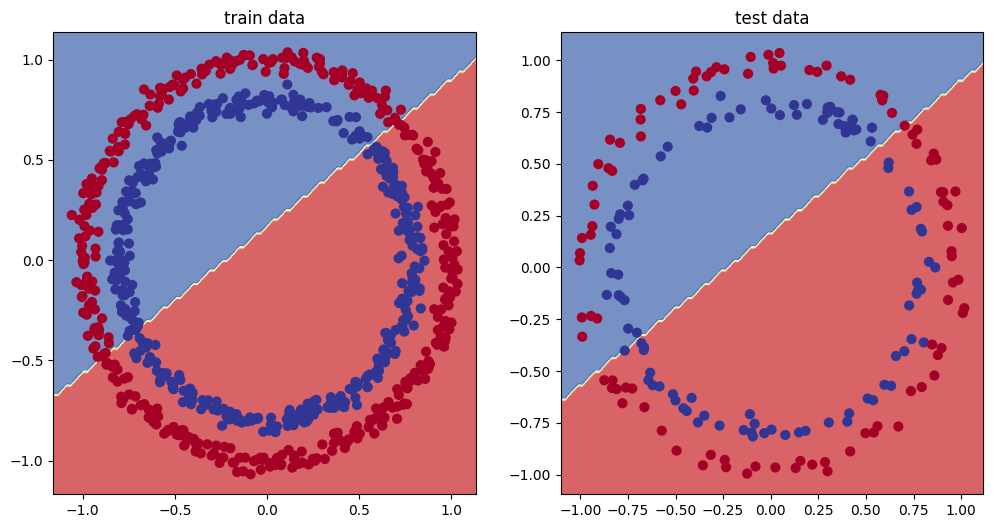

In [34]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train data")
plot_decision_boundary(model_0,X_train,Y_train)
plt.subplot(1,2,2)
plt.title("test data")
plot_decision_boundary(model_0,X_test,Y_test)


our model is not learning because our layers are linear and it is drawing a linear line to separate circular data,so it is not learning effetively.



here's some way to improve the model:

* `add more layers`
* `add more hidden units`
* `changing the actvation function`

In [35]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.0970, -0.2204],
                      [-0.1052,  0.5378],
                      [-0.1226, -0.6291],
                      [-0.6156,  0.2866],
                      [ 0.4450,  0.1721]])),
             ('0.bias', tensor([-0.3431,  0.4050, -0.4572,  0.3965, -0.4669])),
             ('1.weight',
              tensor([[-0.1323, -0.2088, -0.1690,  0.1860,  0.0497]])),
             ('1.bias', tensor([-0.1029]))])

In [36]:
class CircleModelv1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)
  def forward(self,X):
    z=self.layer_1(X)
    z=self.layer_2(z)
    z=self.layer_3(z)
    return z

model_1= CircleModelv1().to(device)
model_1

CircleModelv1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [37]:
# create a loss function
loss_fn=nn.BCEWithLogitsLoss()


# create an optimizer
optimizer= torch.optim.SGD(params=model_1.parameters(),
                           lr=0.1)

In [38]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)


epochs=1000
# put data on cuda for parallel operation
X_test,X_train = X_test.to(device),X_train.to(device)
Y_test,Y_train = Y_test.to(device),Y_train.to(device)



for epoch in range(epochs):
  model_1.train()
  # forward pass
  y_logits=model_1(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))

  # calculate loss
  loss=loss_fn(y_logits,Y_train)
  accuracy=accuracy_fn(y_true=Y_train,
                       y_pred=y_pred)

  # optimizer zero grad
  optimizer.zero_grad()




  # loss backward
  loss.backward()

  # optimizer step
  optimizer.step()


  # testing
  model_1.eval()
  with torch.inference_mode():
    test_logits=model_1(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))
    # calculate the loss
    test_loss=loss_fn(test_logits,Y_test)
    test_acc=accuracy_fn(y_true=Y_test,
                         y_pred=test_pred)

  if epoch % 100 == 0:
    print(f"EPoch:{epoch} | Loss: {loss:.5f} | acc: {accuracy:.2f}% | test_loss:{test_loss:.5f} | test_accuracy:{test_acc:.2f}%")

EPoch:0 | Loss: 0.69396 | acc: 50.88% | test_loss:0.69261 | test_accuracy:51.00%
EPoch:100 | Loss: 0.69305 | acc: 50.38% | test_loss:0.69379 | test_accuracy:48.00%
EPoch:200 | Loss: 0.69299 | acc: 51.12% | test_loss:0.69437 | test_accuracy:46.00%
EPoch:300 | Loss: 0.69298 | acc: 51.62% | test_loss:0.69458 | test_accuracy:45.00%
EPoch:400 | Loss: 0.69298 | acc: 51.12% | test_loss:0.69465 | test_accuracy:46.00%
EPoch:500 | Loss: 0.69298 | acc: 51.00% | test_loss:0.69467 | test_accuracy:46.00%
EPoch:600 | Loss: 0.69298 | acc: 51.00% | test_loss:0.69468 | test_accuracy:46.00%
EPoch:700 | Loss: 0.69298 | acc: 51.00% | test_loss:0.69468 | test_accuracy:46.00%
EPoch:800 | Loss: 0.69298 | acc: 51.00% | test_loss:0.69468 | test_accuracy:46.00%
EPoch:900 | Loss: 0.69298 | acc: 51.00% | test_loss:0.69468 | test_accuracy:46.00%


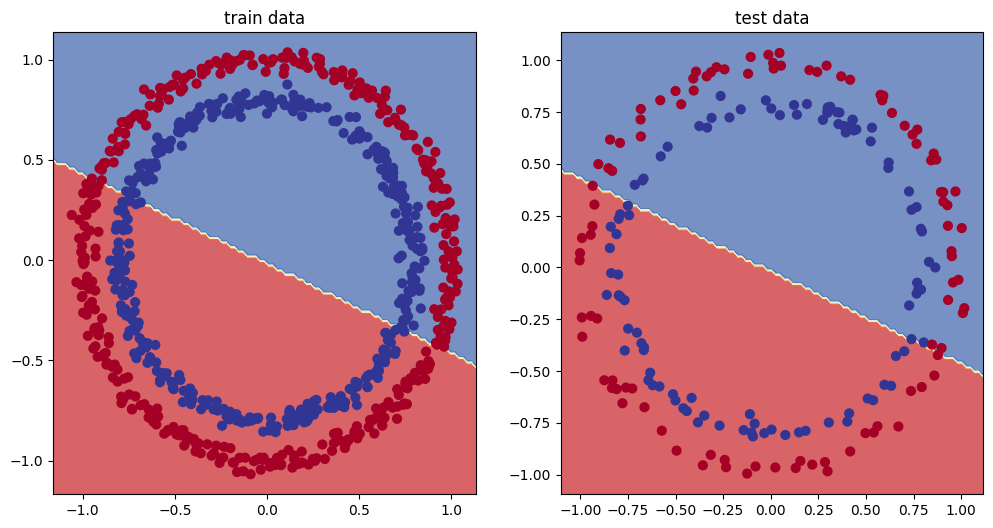

In [39]:
# plot the decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train data")
plot_decision_boundary(model_1,X_train,Y_train)
plt.subplot(1,2,2)
plt.title("test data")
plot_decision_boundary(model_1,X_test,Y_test)


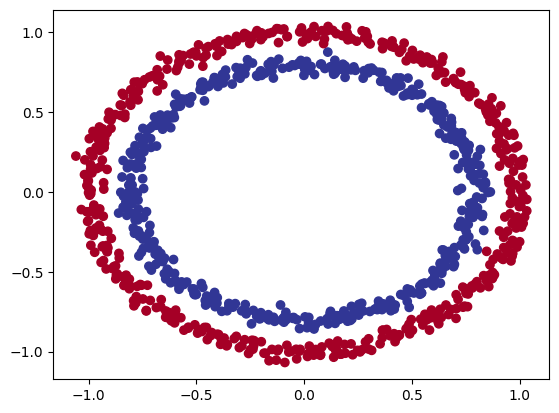

In [40]:
# non linearity
# making and  plotting
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles

n_samples = 1000
X,Y= make_circles(n_samples,
                  noise=0.03,
                  random_state=42)

plt.scatter(X[:,0],X[:, 1], c=Y , cmap=plt.cm.RdYlBu);

In [41]:
# convert data to tensor and then to train and test
import torch
from sklearn.model_selection import train_test_split
X=torch.from_numpy(X).type(torch.float)
Y=torch.from_numpy(Y).type(torch.float)

# split into train test
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,
                                                 test_size=0.2,random_state=42)
X_train[:5] , Y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

##building a model with non linearity

In [42]:
from torch import nn
class Circlemodelv2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2=nn.Linear(in_features=10,out_features=10)
    self.layer_3=nn.Linear(in_features=10,out_features=1)
    self.relu=nn.ReLU()

  def forward(self,X):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(X)))))

model_3= Circlemodelv2().to(device)
model_3

Circlemodelv2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [43]:
# sewtup loss and optimizer.
loss_fn=nn.BCEWithLogitsLoss()

optimizer=torch.optim.SGD(model_3.parameters(),
                          lr=0.1)



In [44]:
# training a model with non linearity\
torch.manual_seed(42)
torch.cuda.manual_seed(42)


X_train,X_test,Y_train,Y_test = X_train.to(device),X_test.to(device),Y_train.to(device),Y_test.to(device)


# loop through data
epochs = 1000
for epoch in range(epochs):
  model_3.train()
  y_logits=model_3(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))

  loss=loss_fn(y_logits,Y_train)

  acc=accuracy_fn(y_true=Y_train,
                  y_pred=y_pred)


  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # teszting
  model_3.eval()
  with torch.inference_mode():
    test_logits=model_3(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))


    test_loss = loss_fn(test_logits,Y_test)
    test_acc=accuracy_fn(y_true=Y_test,y_pred=test_pred)

    if epoch % 100 == 0:
      print(f"Epoch:{epoch} | loss: {loss:.5f} | acc: {acc:.2f}% | test_loss:{test_loss:.5f} | test_acc:{test_acc:.2f}%")




  # model_3.eval()
  # with torch.inference_mode():


Epoch:0 | loss: 0.69295 | acc: 50.00% | test_loss:0.69319 | test_acc:50.00%
Epoch:100 | loss: 0.69115 | acc: 52.88% | test_loss:0.69102 | test_acc:52.50%
Epoch:200 | loss: 0.68977 | acc: 53.37% | test_loss:0.68940 | test_acc:55.00%
Epoch:300 | loss: 0.68795 | acc: 53.00% | test_loss:0.68723 | test_acc:56.00%
Epoch:400 | loss: 0.68517 | acc: 52.75% | test_loss:0.68411 | test_acc:56.50%
Epoch:500 | loss: 0.68102 | acc: 52.75% | test_loss:0.67941 | test_acc:56.50%
Epoch:600 | loss: 0.67515 | acc: 54.50% | test_loss:0.67285 | test_acc:56.00%
Epoch:700 | loss: 0.66659 | acc: 58.38% | test_loss:0.66322 | test_acc:59.00%
Epoch:800 | loss: 0.65160 | acc: 64.00% | test_loss:0.64757 | test_acc:67.50%
Epoch:900 | loss: 0.62362 | acc: 74.00% | test_loss:0.62145 | test_acc:79.00%


In [45]:
# model_3.state_dict()

In [46]:
# making prediction
model_3.eval()
with torch.inference_mode():
  y_preds=torch.round(torch.sigmoid(model_3(X_test)))
y_preds[:10],Y_test[:10]

(tensor([[1.],
         [0.],
         [1.],
         [0.],
         [0.],
         [1.],
         [0.],
         [0.],
         [1.],
         [0.]], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

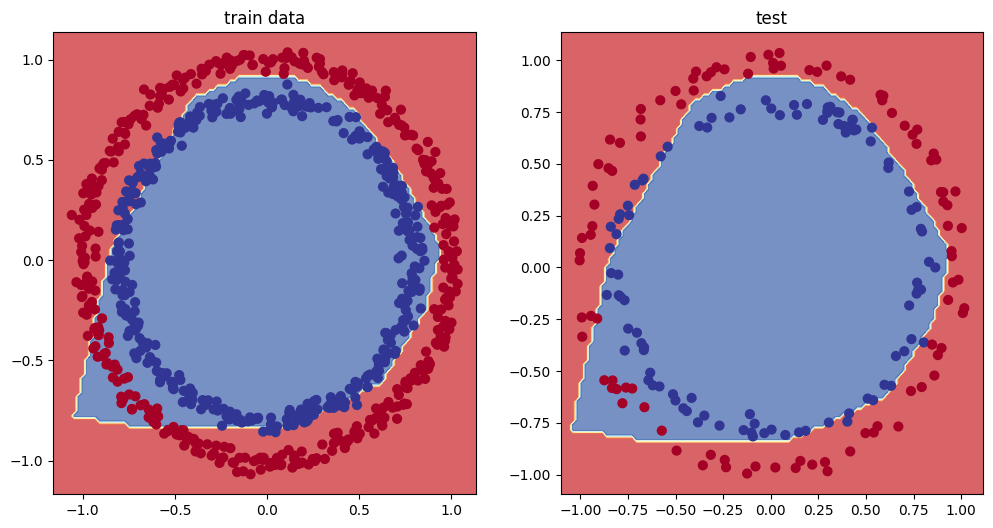

In [47]:
# plot decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train data")
plot_decision_boundary(model_3,X_train,Y_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_3,X_test,Y_test)


## Multi-class classification problem

creating a toy multi-class dataset:


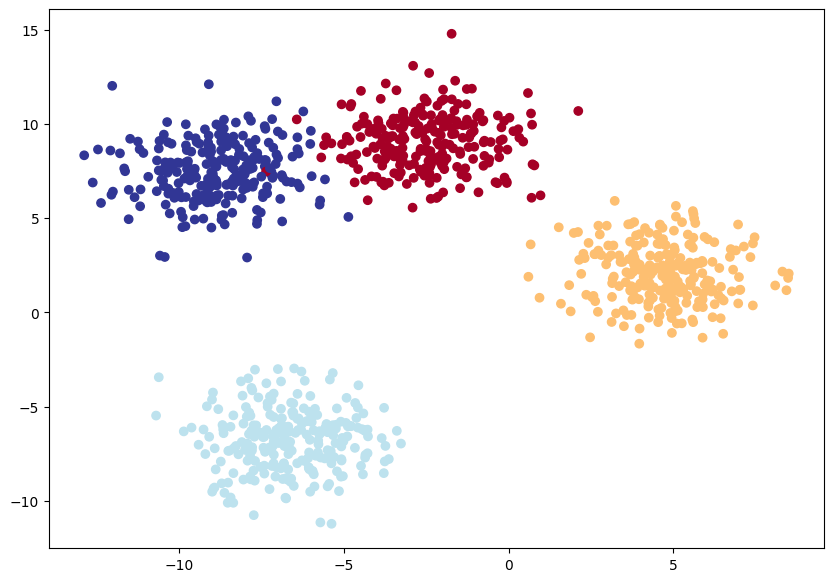

In [48]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split



# set the hyper parameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED =42

# CREATE multiclass data
X_blob,Y_blob =make_blobs(n_samples=1000,
                           n_features=NUM_FEATURES,
                           centers=NUM_CLASSES,
                           cluster_std=1.5,
                           random_state=RANDOM_SEED)

# turn data into tensors
X_blob=torch.from_numpy(X_blob).type(torch.float)
Y_blob=torch.from_numpy(Y_blob).type(torch.LongTensor)


# train test split
X_blob_train,X_blob_test,Y_blob_train,Y_blob_test=train_test_split(X_blob,
                                               Y_blob,
                                               test_size=0.2,
                                               random_state=RANDOM_SEED)


# viusualize the data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1],c=Y_blob,cmap=plt.cm.RdYlBu);

building a model to fit the above data

In [49]:
# creating a device agnostic code
device ="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [50]:
# build a multiclass classification model
class BlobModel(nn.Module):
  def __init__ (self,input_features,output_features,hidden_units=8):
    super().__init__()
    self.linear_layer_stack=nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=output_features)
    )
  def forward(self,X):
    return self.linear_layer_stack(X)


  # creating an instances of BlobModel and send it to the target device
model_4=BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [51]:
# creating a loss _fn,optimier
loss_fn = nn.CrossEntropyLoss()
# create an optimizer
optimizer= torch.optim.SGD(  params= model_4.parameters(),
                           lr=0.1)

In [52]:
# geeting prediction probability for our data
model_4.eval()
with torch.inference_mode():
 y_logits= model_4(X_blob_test.to(device))

y_preds[:10]

tensor([[1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.]], device='cuda:0')

In [53]:
Y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [54]:
# convert out model output logits intoprediction probabilities
y_pred_probs=torch.softmax(y_logits,dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]], device='cuda:0')
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]], device='cuda:0')


In [55]:
torch.argmax(y_pred_probs[0])

tensor(3, device='cuda:0')

In [56]:

# convert our model's prediction probabilities into prediction labels
y_preds = torch.argmax(y_pred_probs,dim=1)
y_preds


tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2,
        2, 2, 3, 3, 3, 3, 3, 1, 1, 2, 1, 2, 1, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3,
        3, 3, 1, 3, 3, 1, 3, 2, 3, 1, 3, 2, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 3, 3, 2, 3, 3, 3, 3, 2, 3, 1, 3, 3, 2, 1, 1, 3, 2, 2, 3, 3, 3, 1, 2,
        2, 3, 3, 1, 2, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 1, 1, 3, 2, 2,
        2, 2, 3, 3, 3, 2, 2, 1, 3, 2, 3, 3, 3, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3,
        2, 2, 2, 3, 3, 1, 1, 1, 1, 1, 3, 1, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 3, 3,
        1, 3, 2, 3, 3, 1, 2, 3], device='cuda:0')

In [57]:
Y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

In [58]:
# creating atraining loop to fit the model to data
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs=100


# put data to target data\
X_blob_train,X_blob_test,Y_blob_train,Y_blob_test = X_blob_train.to(device),X_blob_test.to(device),Y_blob_train.to(device),Y_blob_test.to(device)


for epoch in range(epochs):
  # training
  model_4.train()

  #forward pass
  y_logits=model_4(X_blob_train).squeeze()
  y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)
  loss=loss_fn(y_logits,Y_blob_train)
  acc= accuracy_fn(y_true=Y_blob_train,
                  y_pred=y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()



# testing


  model_4.eval()
  with torch.inference_mode():
    test_logits=model_4(X_blob_test)
    test_pred=torch.softmax(test_logits,dim=1).argmax(dim=1)
    test_loss=loss_fn(test_logits,Y_blob_test)
    test_acc=accuracy_fn(y_true=Y_blob_test,
                        y_pred=test_pred)

  if epoch % 10 == 0:
    print(f"epoch:{epoch}|| loss:{loss:.4f},Acc:{acc:.2f}%|| test loss : {test_loss:.4f},test_acc:{test_acc:.2f}%")


epoch:0|| loss:1.0432,Acc:65.50%|| test loss : 0.5786,test_acc:95.50%
epoch:10|| loss:0.1440,Acc:99.12%|| test loss : 0.1304,test_acc:99.00%
epoch:20|| loss:0.0806,Acc:99.12%|| test loss : 0.0722,test_acc:99.50%
epoch:30|| loss:0.0592,Acc:99.12%|| test loss : 0.0513,test_acc:99.50%
epoch:40|| loss:0.0489,Acc:99.00%|| test loss : 0.0410,test_acc:99.50%
epoch:50|| loss:0.0429,Acc:99.00%|| test loss : 0.0349,test_acc:99.50%
epoch:60|| loss:0.0391,Acc:99.00%|| test loss : 0.0308,test_acc:99.50%
epoch:70|| loss:0.0364,Acc:99.00%|| test loss : 0.0280,test_acc:99.50%
epoch:80|| loss:0.0345,Acc:99.00%|| test loss : 0.0259,test_acc:99.50%
epoch:90|| loss:0.0330,Acc:99.12%|| test loss : 0.0242,test_acc:99.50%


making prediction

In [60]:
model_4.eval()
with torch.inference_mode():
  y_logits= model_4(X_blob_test)


y_logits[:10]

tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711],
        [  1.8400,   7.5599,  -8.6016,  -6.9942],
        [  8.0726,   3.2906, -14.5998,  -3.6186],
        [  5.5844, -14.9521,   5.0168,  13.2890],
        [ -5.9739, -10.1913,  18.8655,   9.9179],
        [  7.0755,  -0.7601,  -9.5531,   0.1736],
        [ -5.5918, -18.5990,  25.5309,  17.5799],
        [  7.3142,   0.7197, -11.2017,  -1.2011]], device='cuda:0')

In [61]:
y_pred_probs=torch.softmax(y_logits,dim=1)
y_pred_probs[:10]

tensor([[2.4332e-03, 9.9757e-01, 1.0804e-11, 1.8271e-09],
        [3.4828e-03, 1.3698e-10, 6.8363e-04, 9.9583e-01],
        [2.8657e-12, 1.2267e-15, 9.9973e-01, 2.6959e-04],
        [3.2692e-03, 9.9673e-01, 9.5436e-08, 4.7620e-07],
        [9.9168e-01, 8.3089e-03, 1.4120e-10, 8.2969e-06],
        [4.5039e-04, 5.4288e-13, 2.5532e-04, 9.9929e-01],
        [1.6306e-11, 2.4030e-13, 9.9987e-01, 1.3003e-04],
        [9.9860e-01, 3.9485e-04, 5.9937e-08, 1.0045e-03],
        [3.0436e-14, 6.8305e-20, 9.9965e-01, 3.5218e-04],
        [9.9843e-01, 1.3657e-03, 9.0768e-09, 2.0006e-04]], device='cuda:0')

In [62]:
y_preds=torch.argmax(y_pred_probs,dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')

In [65]:
Y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')

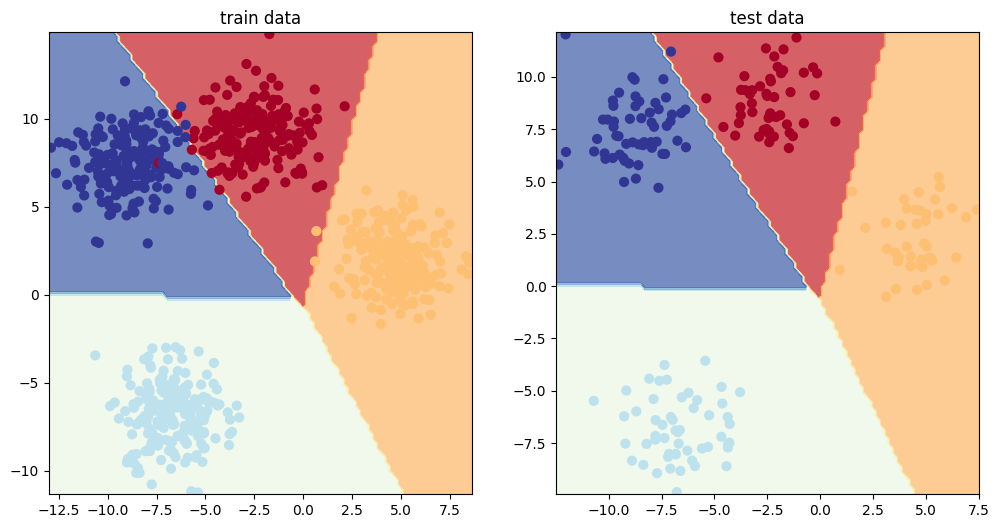

In [66]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train data")
plot_decision_boundary(model_4,X_blob_train,Y_blob_train)
plt.subplot(1,2,2)
plt.title("test data")
plot_decision_boundary(model_4,X_blob_test,Y_blob_test)